In [1]:
import os
import pandas as pd
import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from accelerate import Accelerator
import torch
from torchvision import transforms
from diffusers import (
    StableDiffusionPipeline,
    DDPMScheduler,
    UNet2DConditionModel,
    AutoencoderKL
)
from safetensors.torch import load_file
from PIL import Image
import os
from os.path import join
import sys
from tqdm import tqdm
WORKSHOP = '/usr/local/data/zahrat/workshop'
sys.path.insert(0, join(WORKSHOP, 'stable-diffusion-finetune'))
sys.path.append(join(WORKSHOP, 'med-classifiers/src'))

/usr/local/data/zahrat/workshop/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
image_root_path = "/usr/local/faststorage/datasets/zahrat/ham10000"
df = pd.read_csv('/usr/local/data/zahrat/workshop/dent/data/ham10k_metadata.csv')
checkpoint_path = '/usr/local/data/zahrat/workshop/dent/saved_models/ham10k-finetuned/checkpoint-99-0/model.safetensors'
classifier_checkpoint = '/usr/local/data/zahrat/workshop/med-classifiers/saved_models/7classes/best_model_512_2025-01-30_12-26-51.pth'
device = 'cuda'

In [3]:
def set_image_paths(df):
    image_paths = []

    for index, row in df.iterrows():
        image_id = row['image_id']
        
        base1_path = os.path.join(image_root_path, 'HAM10000_images_part_1')
        base2_path = os.path.join(image_root_path, 'HAM10000_images_part_2')
        
        image_path_1 = os.path.join(base1_path, f'{image_id}.jpg')
        image_path_2 = os.path.join(base2_path, f'{image_id}.jpg')

        if os.path.exists(image_path_1):
            image_paths.append(image_path_1)
        elif os.path.exists(image_path_2):
            image_paths.append(image_path_2)
        else:
            print(f'Image {image_id} not found in either path.')

        # Add the image paths to your DataFrame
    df['image_path'] = image_paths
    return df
    

df_test = set_image_paths(df[df['split'] == 'test'])

/tmp/ipykernel_379674/1452417306.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['image_path'] = image_paths


# EfficientNet

In [4]:
imgs = []
labels = []
for i, row in df_test.iterrows():
    imgs.append(Image.open(row['image_path']).convert('RGB'))
    labels.append(row['dx'])

In [5]:
from ham10k_efficientnet import HAM10KClassifier

size = 512
transform = transforms.Compose([
    transforms.Resize((size, size)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

classifier = HAM10KClassifier()
checkpoint = torch.load(classifier_checkpoint)
classifier.load_state_dict(checkpoint['model_state_dict'])
classifier.model.classifier = torch.nn.Identity()
classifier.to(device)
classifier.eval()

classifier_transform = transforms.Compose([
    transforms.Resize((512, 512)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

/usr/local/data/zahrat/workshop/venv/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/data/zahrat/workshop/venv/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [22]:
img_features = []
for img in tqdm(imgs):
    img = transform(img).unsqueeze(0).to(device)
    with torch.no_grad():
        features = classifier.model(img)
    img_features.append(features.cpu().numpy().flatten())

100%|██████████| 1995/1995 [00:29<00:00, 67.13it/s]


In [23]:
img_features = np.array(img_features)
img_features.shape

(1995, 1280)

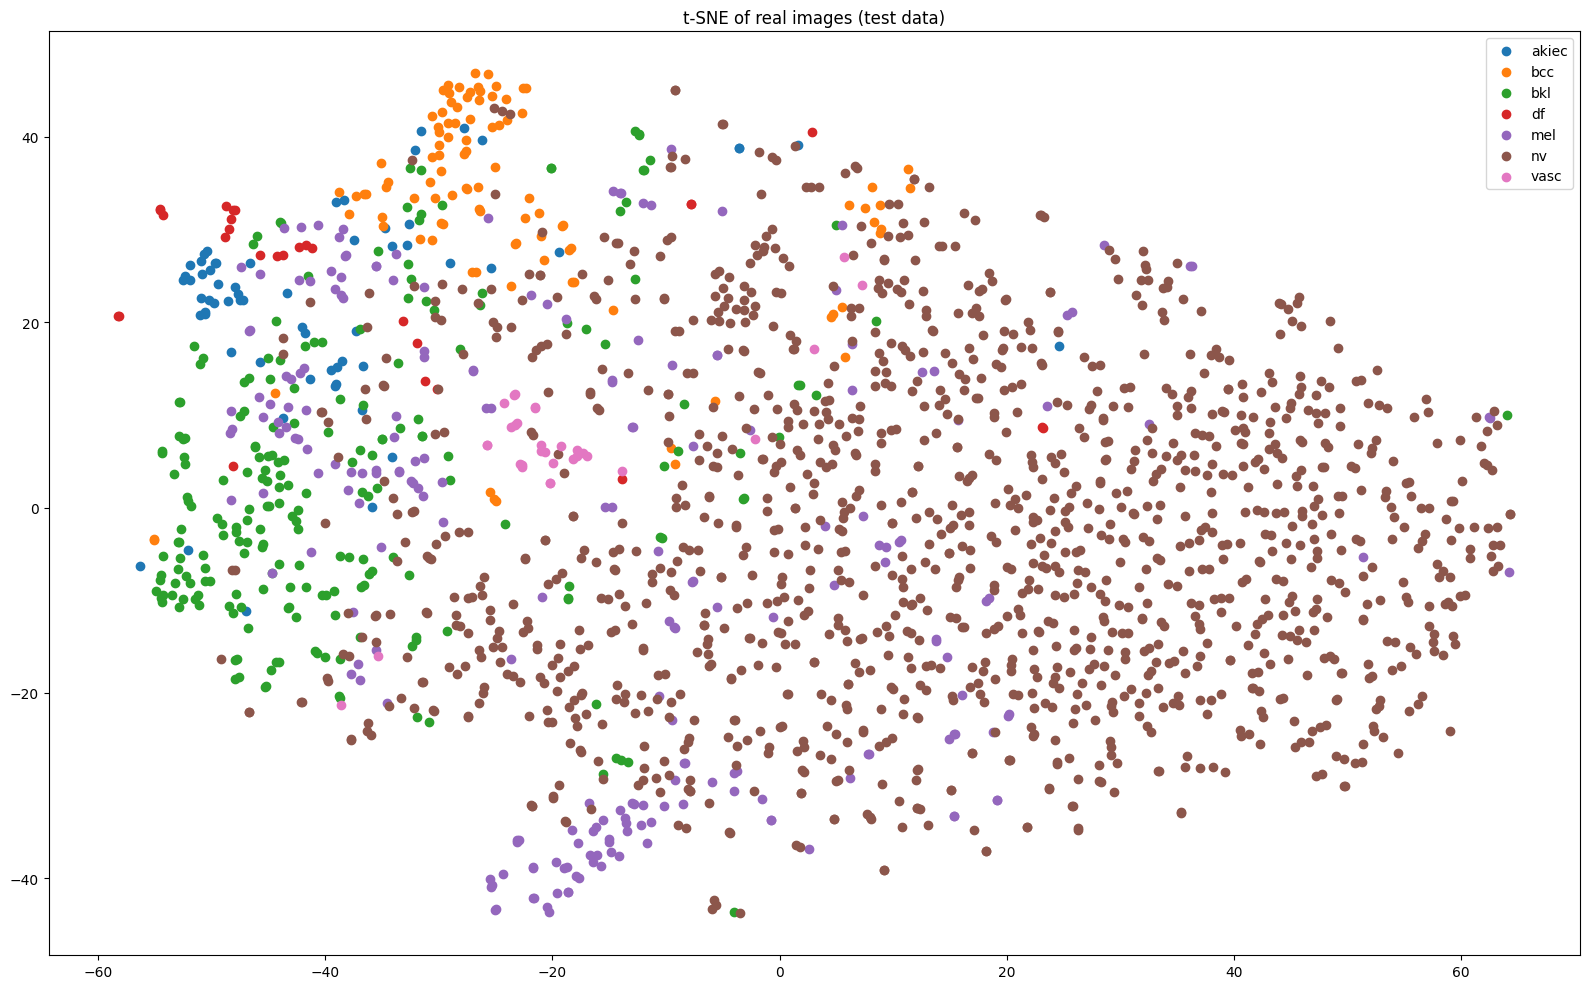

In [26]:
tsne = TSNE(n_components=2, random_state=42)
tsne_results = tsne.fit_transform(img_features)

unique_labels = np.unique(labels)
colors = plt.cm.tab10(range(len(unique_labels)))
labels = np.array(labels)
plt.figure(figsize=(16,10))
for label, color in zip(unique_labels, colors):
    mask = (labels == label)
    plt.scatter(tsne_results[mask,0], tsne_results[mask,1], label=label, color=color)
plt.title('t-SNE of real images (test data)')
plt.legend()

plt.tight_layout()
plt.savefig('../outputs/figures/tsne_efficientnet_real_images.png')

In [10]:
synthetic_images_folder = '/usr/local/data/zahrat/workshop/dent/outputs/ham10000-classifier-guided'
classes = ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']

synthetic_image_features = []
synthetic_image_labels = []

for c in classes:
    synthetic_images = os.listdir(join(synthetic_images_folder, c))

    for img in tqdm(synthetic_images):
        img = Image.open(join(synthetic_images_folder, c, img)).convert('RGB')
        img = transform(img).unsqueeze(0).to(device)
        with torch.no_grad():
            features = classifier.model(img)
            
        img_features = features.cpu().numpy().flatten()
        synthetic_image_features.append(img_features)
        synthetic_image_labels.append(c)

synthetic_image_features = np.array(synthetic_image_features)  


100%|██████████| 100/100 [00:19<00:00,  5.19it/s]


In [28]:
tsne = TSNE(n_components=2, random_state=42)
tsne_results = tsne.fit_transform(synthetic_image_features)

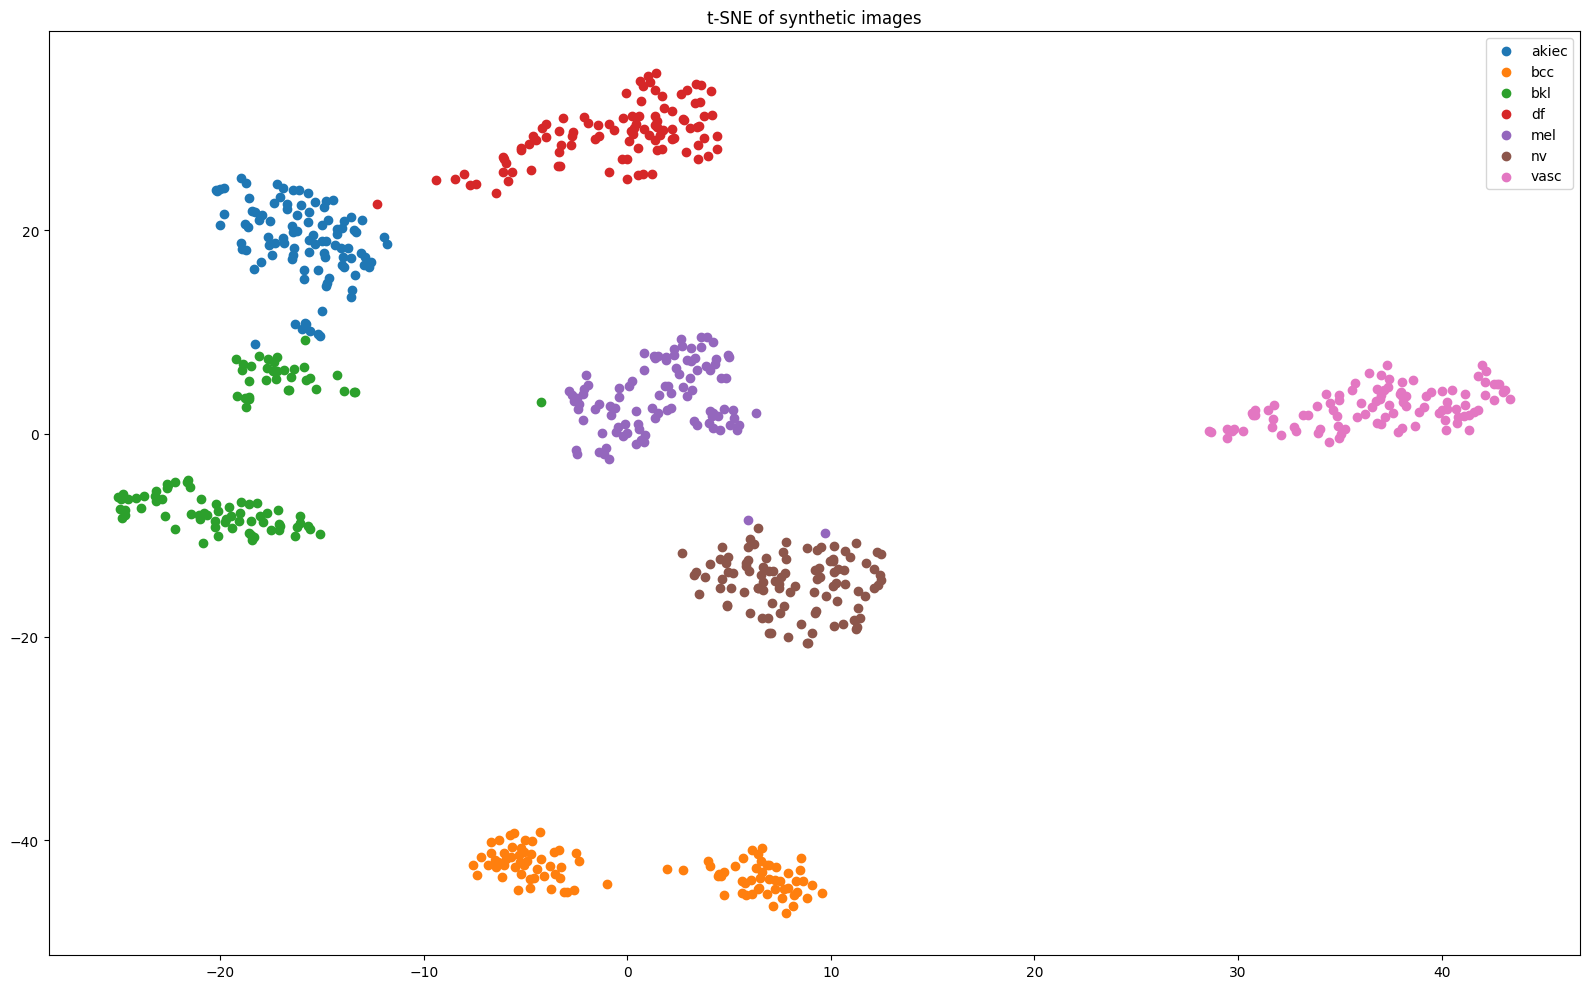

In [30]:
plt.figure(figsize=(16,10))    
plt.title('t-SNE of synthetic images')

for label, color in zip(unique_labels, colors):
    mask = (np.array(synthetic_image_labels) == str(label))
    plt.scatter(tsne_results[mask,0], tsne_results[mask,1], label=label, color=color)
plt.legend()
plt.tight_layout()
plt.savefig('../outputs/figures/tsne_efficientnet_synthetic_images.png')
